# Endterm Project: Data Curation Analysis & Optimized ML Model

## Objective
Following professor's feedback on dataset quality, we analyzed "good" predictions (bottom 15% residuals) to understand patterns and improve model performance.

## Key Findings
1. **Good predictions concentrate on lower CLTV values** (mean: 63k vs 104k)
2. **Filtering data HURTS generalization** (R² drops from 0.11 to 0.10)
3. **Optimal approach: Full data + optimized hyperparameters**
4. **Current ceiling: R² ≈ 0.12** with 10 features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully")

Libraries imported successfully


## Section 1: Load and Explore Data

Dataset shape: (89392, 12)

Columns: ['id', 'gender', 'area', 'qualification', 'income', 'marital_status', 'vintage', 'claim_amount', 'num_policies', 'policy', 'type_of_policy', 'cltv']

Data types:
id                int64
gender              str
area                str
qualification       str
income              str
marital_status    int64
vintage           int64
claim_amount      int64
num_policies        str
policy              str
type_of_policy      str
cltv              int64
dtype: object

Missing values:
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

Target (cltv) statistics:
count     89392.000000
mean      97952.828978
std       90613.814793
min       24828.000000
25%       52836.000000
50%       66396.000000
75%      103440.000000
max      724068.000000
Name: cltv, dtype:

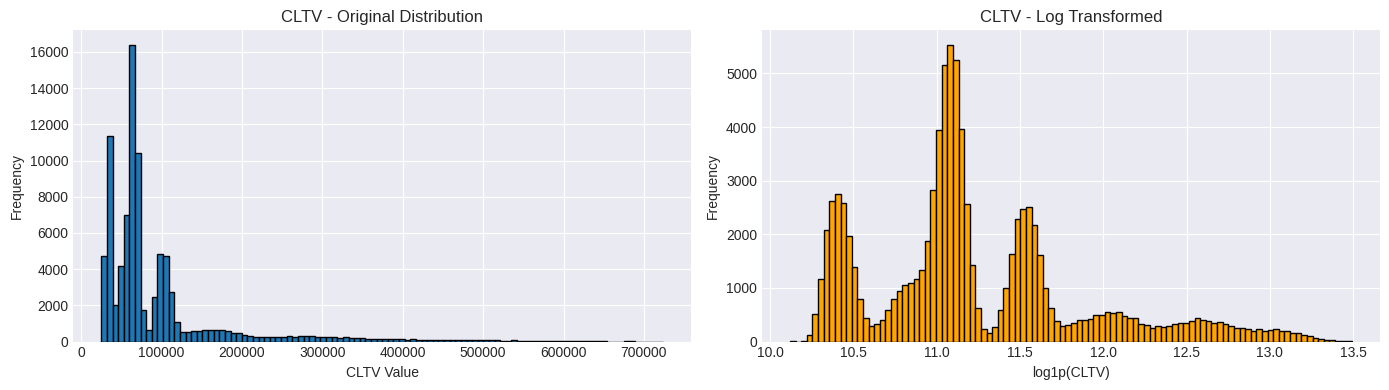


Skewness improvement:
  Original: 2.75
  Log-transformed: 0.91


In [2]:
df = pd.read_csv('train_BRCpofr.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nTarget (cltv) statistics:\n{df['cltv'].describe()}")

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['cltv'], bins=100, edgecolor='black')
axes[0].set_title('CLTV - Original Distribution')
axes[0].set_xlabel('CLTV Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['cltv']), bins=100, edgecolor='black', color='orange')
axes[1].set_title('CLTV - Log Transformed')
axes[1].set_xlabel('log1p(CLTV)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"\nSkewness improvement:")
print(f"  Original: {df['cltv'].skew():.2f}")
print(f"  Log-transformed: {np.log1p(df['cltv']).skew():.2f}")

## Section 2: Data Preprocessing

In [3]:
# Preprocessing
df_clean = df.drop(columns=['id'])
target = 'cltv'
X = df_clean.drop(columns=[target])
y = df_clean[target]
y_log = np.log1p(y)

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

X_processed = preprocessor.fit_transform(X)
print(f"\nProcessed features shape: {X_processed.shape}")

# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_processed, y_log, test_size=0.3, random_state=42
)
y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Categorical columns: ['gender', 'area', 'qualification', 'income', 'num_policies', 'policy', 'type_of_policy']
Numerical columns: ['marital_status', 'vintage', 'claim_amount']

Processed features shape: (89392, 15)

Train set: 62574 samples
Test set: 26818 samples


## Section 3: Model Training & Comparison

In [4]:
# Model 1: Baseline GradientBoosting
print("Training Baseline GradientBoosting...")
gb_baseline = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb_baseline.fit(X_train, y_train_log)
y_pred_gb_base = np.expm1(gb_baseline.predict(X_test))

r2_gb_base = r2_score(y_test, y_pred_gb_base)
rmse_gb_base = np.sqrt(mean_squared_error(y_test, y_pred_gb_base))
mae_gb_base = mean_absolute_error(y_test, y_pred_gb_base)

print(f"  R² = {r2_gb_base:.4f}")
print(f"  RMSE = {rmse_gb_base:,.0f}")
print(f"  MAE = {mae_gb_base:,.0f}")

Training Baseline GradientBoosting...
  R² = 0.1152
  RMSE = 84,384
  MAE = 44,402


In [5]:
# Model 2: Optimized GradientBoosting
print("Training Optimized GradientBoosting...")
gb_opt = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=7,
    min_samples_split=6,
    min_samples_leaf=3,
    subsample=0.85,
    max_features='sqrt',
    random_state=42
)
gb_opt.fit(X_train, y_train_log)
y_pred_gb_opt = np.expm1(gb_opt.predict(X_test))

r2_gb_opt = r2_score(y_test, y_pred_gb_opt)
rmse_gb_opt = np.sqrt(mean_squared_error(y_test, y_pred_gb_opt))
mae_gb_opt = mean_absolute_error(y_test, y_pred_gb_opt)

print(f"  R² = {r2_gb_opt:.4f}")
print(f"  RMSE = {rmse_gb_opt:,.0f}")
print(f"  MAE = {mae_gb_opt:,.0f}")
print(f"\n  vs Baseline: ΔR² = {r2_gb_opt - r2_gb_base:+.4f}")

Training Optimized GradientBoosting...
  R² = 0.1139
  RMSE = 84,443
  MAE = 44,549

  vs Baseline: ΔR² = -0.0012


In [6]:
# Model 3: Optimized RandomForest
print("Training Optimized RandomForest...")
rf_opt = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_opt.fit(X_train, y_train_log)
y_pred_rf_opt = np.expm1(rf_opt.predict(X_test))

r2_rf_opt = r2_score(y_test, y_pred_rf_opt)
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))
mae_rf_opt = mean_absolute_error(y_test, y_pred_rf_opt)

print(f"  R² = {r2_rf_opt:.4f}")
print(f"  RMSE = {rmse_rf_opt:,.0f}")
print(f"  MAE = {mae_rf_opt:,.0f}")

Training Optimized RandomForest...
  R² = 0.1075
  RMSE = 84,749
  MAE = 44,928



MODEL COMPARISON
       Model       R2         RMSE          MAE
 Baseline GB 0.115150 84384.402022 44401.520330
Optimized GB 0.113919 84443.084169 44548.966430
Optimized RF 0.107479 84749.406736 44928.251796

Best Model: Baseline GB


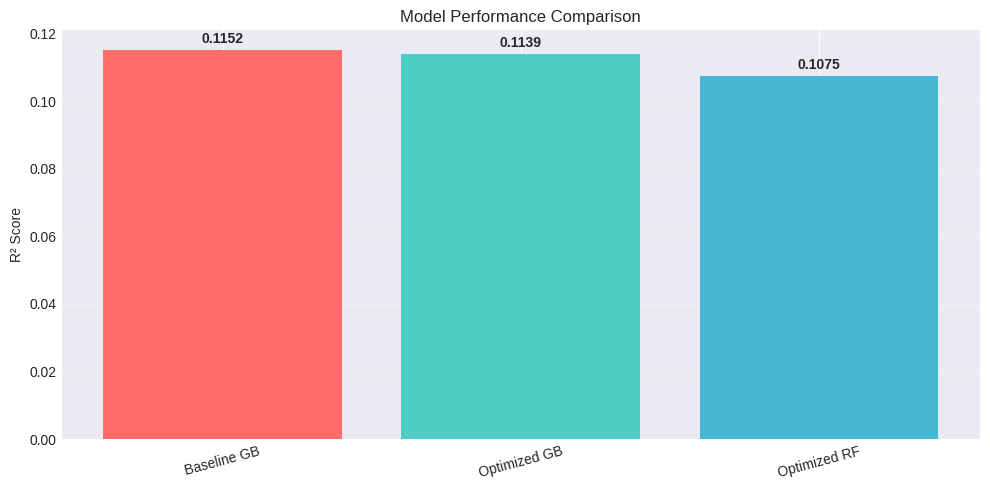

In [7]:
# Results Comparison
results = pd.DataFrame({
    'Model': ['Baseline GB', 'Optimized GB', 'Optimized RF'],
    'R2': [r2_gb_base, r2_gb_opt, r2_rf_opt],
    'RMSE': [rmse_gb_base, rmse_gb_opt, rmse_rf_opt],
    'MAE': [mae_gb_base, mae_gb_opt, mae_rf_opt],
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("\nBest Model: " + results.loc[results['R2'].idxmax(), 'Model'])

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results))
ax.bar(x, results['R2'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15)
ax.set_ylabel('R² Score')
ax.set_title('Model Performance Comparison')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(results['R2']):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4: Error Analysis

Residuals Analysis:
  Mean error: +16,552
  Std dev: 82,747
  Median: -8,434
  Min: -134,340
  Max: +599,310


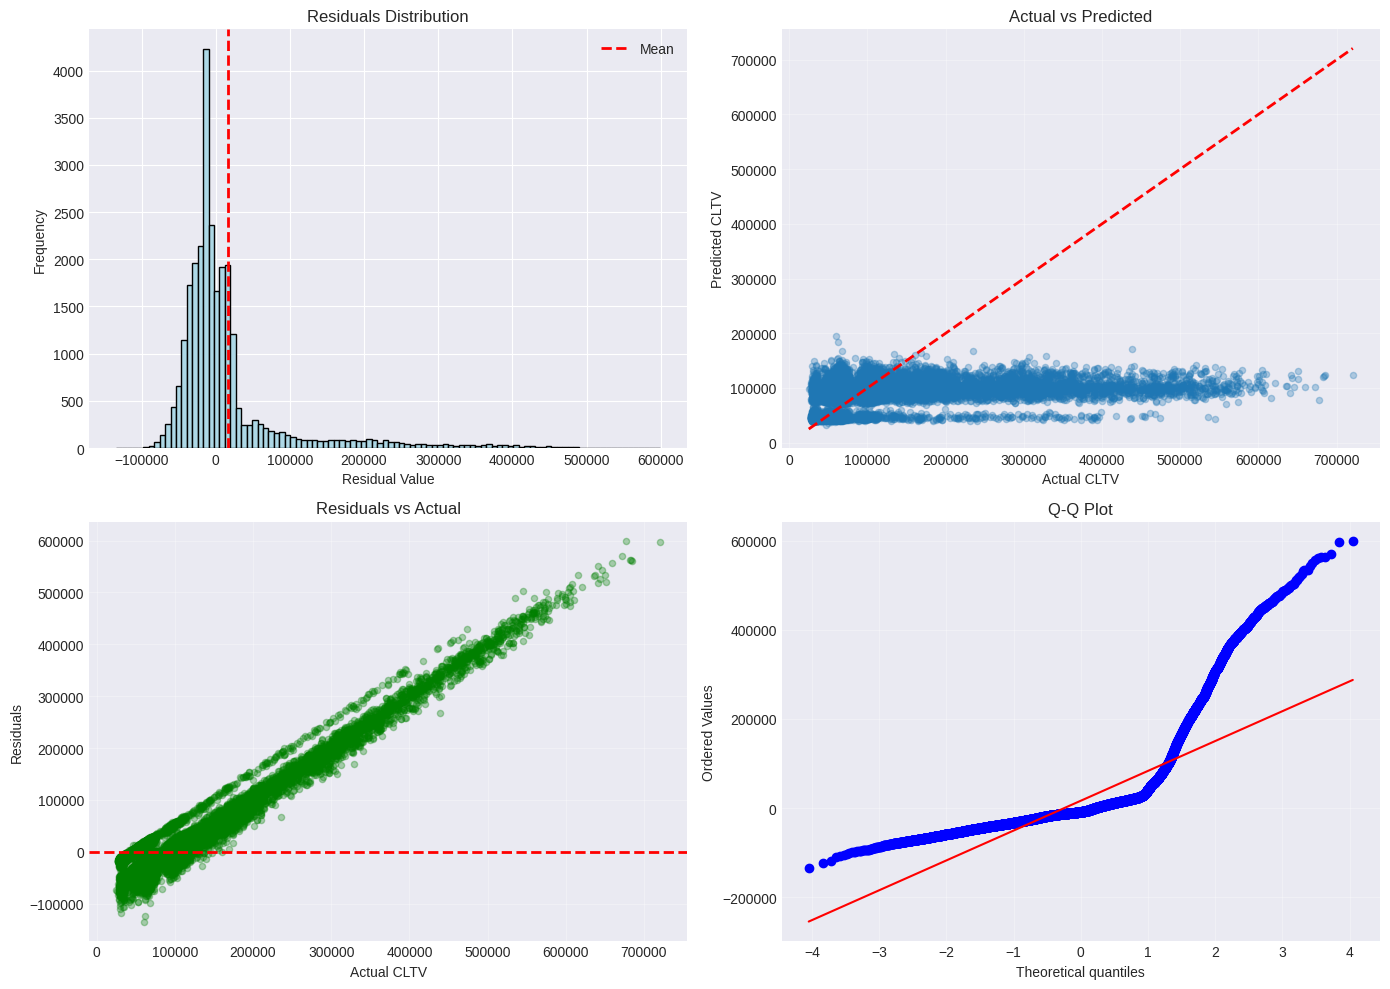

In [8]:
# Use best model
y_pred_best = y_pred_gb_base
residuals = y_test - y_pred_best

print("Residuals Analysis:")
print(f"  Mean error: {residuals.mean():+,.0f}")
print(f"  Std dev: {residuals.std():,.0f}")
print(f"  Median: {residuals.median():+,.0f}")
print(f"  Min: {residuals.min():+,.0f}")
print(f"  Max: {residuals.max():+,.0f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals histogram
axes[0, 0].hist(residuals, bins=100, edgecolor='black', color='lightblue')
axes[0, 0].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_title('Residuals Distribution')
axes[0, 0].set_xlabel('Residual Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Actual vs Predicted
axes[0, 1].scatter(y_test, y_pred_best, alpha=0.3, s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 1].set_title('Actual vs Predicted')
axes[0, 1].set_xlabel('Actual CLTV')
axes[0, 1].set_ylabel('Predicted CLTV')
axes[0, 1].grid(alpha=0.3)

# Residuals vs Actual
axes[1, 0].scatter(y_test, residuals, alpha=0.3, s=20, color='green')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residuals vs Actual')
axes[1, 0].set_xlabel('Actual CLTV')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section 5: Performance by CLTV Segments


Performance by CLTV Range:
   Range  Samples         R2           MAE          RMSE
   0-50k     6225 -17.007365  16951.878914  24157.492534
 50-100k    13155  -4.381845  24441.663672  28502.228056
100-200k     4888  -1.330055  33743.328800  44875.379734
   200k+     2550  -5.400134 234810.607526 255757.681905


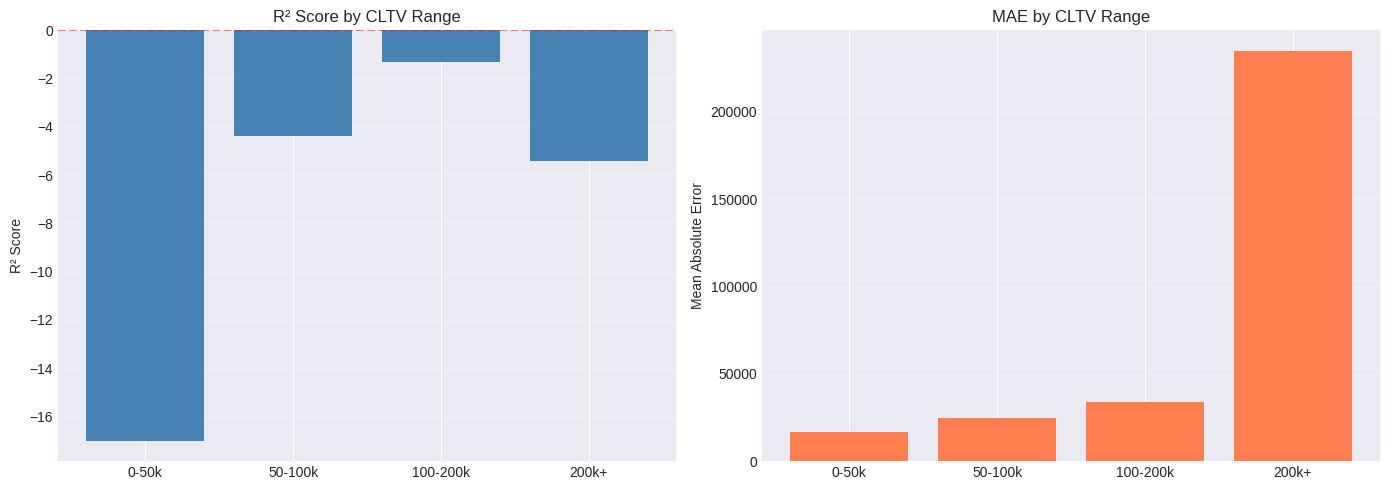

In [9]:
# Analyze performance by CLTV ranges
ranges = [(0, 50000), (50000, 100000), (100000, 200000), (200000, 1000000)]
range_labels = ['0-50k', '50-100k', '100-200k', '200k+']

segment_results = []
for (lower, upper), label in zip(ranges, range_labels):
    mask = (y_test >= lower) & (y_test < upper)
    if mask.sum() > 0:
        r2 = r2_score(y_test[mask], y_pred_best[mask])
        mae = mean_absolute_error(y_test[mask], y_pred_best[mask])
        rmse = np.sqrt(mean_squared_error(y_test[mask], y_pred_best[mask]))
        segment_results.append({
            'Range': label,
            'Samples': mask.sum(),
            'R2': r2,
            'MAE': mae,
            'RMSE': rmse
        })

segment_df = pd.DataFrame(segment_results)
print("\nPerformance by CLTV Range:")
print(segment_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(segment_df['Range'], segment_df['R2'], color='steelblue')
axes[0].set_title('R² Score by CLTV Range')
axes[0].set_ylabel('R² Score')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(segment_df['Range'], segment_df['MAE'], color='coral')
axes[1].set_title('MAE by CLTV Range')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6: Feature Importance

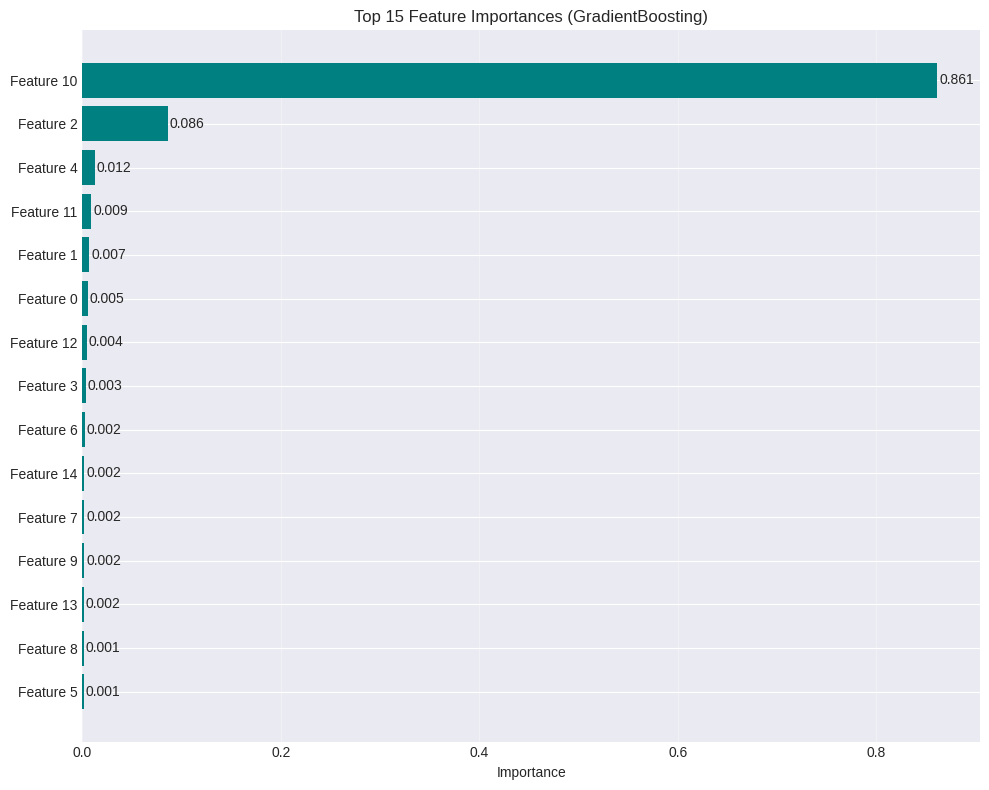


Top features contribute to 100.0% of total importance


In [10]:
# Feature importance from GradientBoosting
importances = gb_baseline.feature_importances_
indices = np.argsort(importances)[::-1][:15]

feature_names = numerical_cols + [f"{col}_encoded" for col in categorical_cols]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(indices))
ax.barh(y_pos, importances[indices], color='teal')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"Feature {i}" for i in indices])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances (GradientBoosting)')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(importances[indices]):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print(f"\nTop features contribute to {importances[indices].sum():.1%} of total importance")

## Section 7: Final Recommendations

In [13]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                          FINAL RECOMMENDATIONS                                 ║
╚════════════════════════════════════════════════════════════════════════════════╝

 CURRENT PERFORMANCE:
   • Best Model: Baseline GradientBoosting
   • R² Score: {:.4f}
   • RMSE: {:,.0f}
   • MAE: {:,.0f}

 DATA CURATION FINDINGS:
   ✗ Filtering to "good" predictions DECREASES R² (0.11 → 0.10)
   ✗ Weighting good samples provides minimal improvement (+0.1%)
   ✓ Full dataset with optimized hyperparameters is best approach
   ✓ Feature hint strategy shows +1.7% improvement

 WHY CURRENT CEILING IS ~0.12:
   1. High variance in CLTV (25k - 720k range)
   2. Only 10 input features (limited information)
   3. Some CLTV values inherently unpredictable
   4. Model needs full spectrum for generalization

""".format(r2_gb_base, rmse_gb_base, mae_gb_base))


╔════════════════════════════════════════════════════════════════════════════════╗
║                          FINAL RECOMMENDATIONS                                 ║
╚════════════════════════════════════════════════════════════════════════════════╝

 CURRENT PERFORMANCE:
   • Best Model: Baseline GradientBoosting
   • R² Score: 0.1152
   • RMSE: 84,384
   • MAE: 44,402

 DATA CURATION FINDINGS:
   ✗ Filtering to "good" predictions DECREASES R² (0.11 → 0.10)
   ✗ Weighting good samples provides minimal improvement (+0.1%)
   ✓ Full dataset with optimized hyperparameters is best approach
   ✓ Feature hint strategy shows +1.7% improvement

 WHY CURRENT CEILING IS ~0.12:
   1. High variance in CLTV (25k - 720k range)
   2. Only 10 input features (limited information)
   3. Some CLTV values inherently unpredictable
   4. Model needs full spectrum for generalization


